In [20]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
import os 
from utils import BinnedStimSpikeDataset, bin_spike_response, open_model_and_data
from viz import compute_avg_spikes_across_trials
import yaml
from metrics import *

n_neurons = 63
n_stim_channels = 42


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [21]:
SWEEP_DIR = 'results/multilayer_cnn_nohist_sweep_v2_2026-02-24_22-05-22/trial_0147_history=1_kernel_sizes=5_conv_channels=256_fc_dims=256/'
history_model, history_cfg, history_raw, test_loader = open_model_and_data(SWEEP_DIR)
nonhistory_model, nonhistory_cfg, nonhistory_raw, nonhistory_test_loader = open_model_and_data('results/base_cnn_sweep3_2026-02-20_11-17-00/trial_0025/')


Loading data …
63 unique neurons after dropping problematic neurons
Stimulation channels: 42, Spiking neurons: 63
Unique patterns: 4050, Total trials: 5000
806 trials were added in spike responses for initial state that were not in the specified trial_indices
Loading data …
63 unique neurons after dropping problematic neurons
Stimulation channels: 42, Spiking neurons: 63
Unique patterns: 4050, Total trials: 5000
806 trials were added in spike responses for initial state that were not in the specified trial_indices


In [49]:

from models import predict_autoregressive
from scipy.stats import pearsonr

COARSE_BIN_MS = 60
fine_bin_ms = 10  # 10 ms
factor = COARSE_BIN_MS // fine_bin_ms  # 6
# factor = 0  # Set to 0 to disable coarsening and use original fine bins
print(f"=== Correlation at {COARSE_BIN_MS}ms resolution per neuron ===")

# ----- Compute all three teacher-forced / LOO -----
hist_corrs    = get_per_neuron_temporal_corr(history_model, test_loader, coarse_factor=factor)
nohist_corrs  = get_per_neuron_temporal_corr(nonhistory_model, nonhistory_test_loader, coarse_factor=factor)
loo_corrs     = get_loo_temporal_corr(test_loader.dataset, coarse_factor=factor)   # LOO only depends on ground truth

print(f"History model   — mean r = {hist_corrs.mean():.4f}  (median {np.median(hist_corrs):.4f})")
print(f"No-history model — mean r = {nohist_corrs.mean():.4f}  (median {np.median(nohist_corrs):.4f})")
print(f"LOO average      — mean r = {loo_corrs.mean():.4f}  (median {np.median(loo_corrs):.4f})")
print(f"Neurons history > LOO:    {(hist_corrs > loo_corrs).sum()}/{len(loo_corrs)}")
print(f"Neurons no-history > LOO: {(nohist_corrs > loo_corrs).sum()}/{len(loo_corrs)}")

# ----- Autoregressive predictions -----
print(f"\n=== Computing autoregressive predictions... ===")
ar_pred, ar_true = predict_autoregressive(history_model, test_loader, chunk_length=None, coarse_factor=factor)

# Per-neuron AR correlation
n_neurons_here = ar_pred.shape[1]
ar_corrs = np.zeros(n_neurons_here)
for n in range(n_neurons_here):
    p = ar_pred[:, n, :].ravel()
    t = ar_true[:, n, :].ravel()
    if p.std() > 1e-8 and t.std() > 1e-8:
        ar_corrs[n] = pearsonr(p, t)[0]
print(f"History AR model — mean r = {ar_corrs.mean():.4f}  (median {np.median(ar_corrs):.4f})")
print(f"Neurons AR > LOO:         {(ar_corrs > loo_corrs).sum()}/{len(loo_corrs)}")

# --- Fraction of Variance Explained (FVE) for all four predictors ---
hist_pred, hist_true     = collect_model_preds_and_targets(history_model, test_loader, coarse_factor=factor)
nohist_pred, nohist_true = collect_model_preds_and_targets(nonhistory_model, nonhistory_test_loader, coarse_factor=factor)
loo_pred, loo_true       = collect_loo_preds_and_targets(test_loader.dataset, coarse_factor=factor, loo_flag=True)

hist_fve_neurons, hist_fve_mean       = fraction_variance_explained(hist_true, hist_pred, global_variance=True)
nohist_fve_neurons, nohist_fve_mean   = fraction_variance_explained(nohist_true, nohist_pred, global_variance=True)
loo_fve_neurons, loo_fve_mean         = fraction_variance_explained(loo_true, loo_pred, global_variance=True)
ar_fve_neurons, ar_fve_mean           = fraction_variance_explained(ar_true, ar_pred, global_variance=True)

print(f"\n=== Fraction of Variance Explained (FVE) per neuron at {COARSE_BIN_MS}ms resolution ===")
print(f"History model    — mean FVE = {hist_fve_mean:.4f}  (median {np.median(hist_fve_neurons):.4f})")
print(f"History AR model — mean FVE = {ar_fve_mean:.4f}  (median {np.median(ar_fve_neurons):.4f})")
print(f"No-history model — mean FVE = {nohist_fve_mean:.4f}  (median {np.median(nohist_fve_neurons):.4f})")
print(f"LOO average      — mean FVE = {loo_fve_mean:.4f}  (median {np.median(loo_fve_neurons):.4f})")
print(f"Neurons history > LOO:    {(hist_fve_neurons > loo_fve_neurons).sum()}/{len(loo_fve_neurons)}")
print(f"Neurons AR > LOO:         {(ar_fve_neurons > loo_fve_neurons).sum()}/{len(loo_fve_neurons)}")
print(f"Neurons no-history > LOO: {(nohist_fve_neurons > loo_fve_neurons).sum()}/{len(loo_fve_neurons)}")


=== Correlation at 60ms resolution per neuron ===
History model   — mean r = 0.5445  (median 0.5572)
No-history model — mean r = 0.3666  (median 0.3401)
LOO average      — mean r = 0.5174  (median 0.5274)
Neurons history > LOO:    34/63
Neurons no-history > LOO: 0/63

=== Computing autoregressive predictions... ===


History AR model — mean r = 0.3656  (median 0.3603)
Neurons AR > LOO:         1/63

=== Fraction of Variance Explained (FVE) per neuron at 60ms resolution ===
History model    — mean FVE = 0.3007  (median 0.2807)
History AR model — mean FVE = 0.1067  (median 0.0859)
No-history model — mean FVE = 0.1449  (median 0.1106)
LOO average      — mean FVE = 0.2881  (median 0.2743)
Neurons history > LOO:    35/63
Neurons AR > LOO:         1/63
Neurons no-history > LOO: 2/63


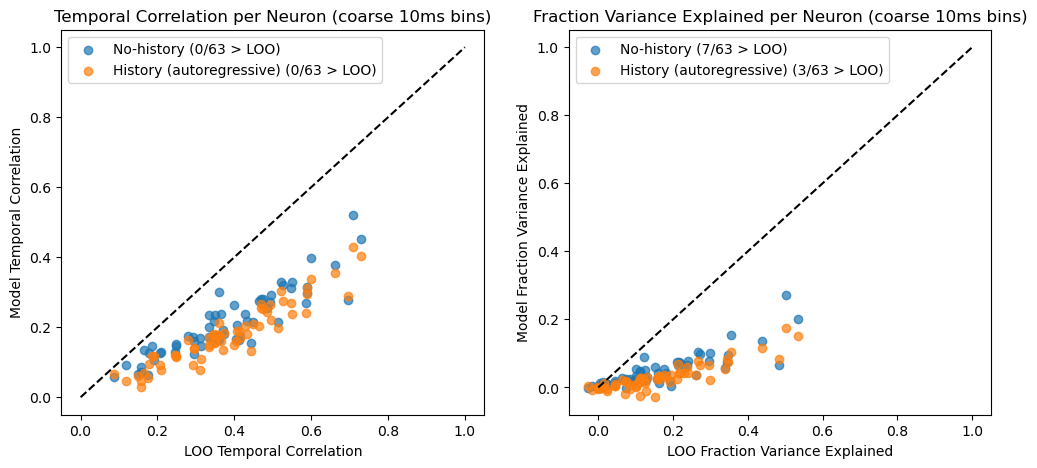

In [29]:

import matplotlib.pyplot as plt

# Pre-computed per-neuron arrays for each "model" variant
MODEL_DATA = {
    'hist_gt': {
        'corrs': hist_corrs,
        'fve': hist_fve_neurons,
        'label': 'History (ground-truth)',
    },
    'hist_ar': {
        'corrs': ar_corrs,
        'fve': ar_fve_neurons,
        'label': 'History (autoregressive)',
    },
    'nohist': {
        'corrs': nohist_corrs,
        'fve': nohist_fve_neurons,
        'label': 'No-history',
    },
}

def plot_model_comparison(model_a, model_b,
                          loo_corrs, loo_fve,
                          coarse_bin_ms,
                          save_path=None):
    """Scatter-plot two models against the LOO baseline (correlation & FVE).

    Parameters
    ----------
    model_a, model_b : str
        Key into MODEL_DATA: 'hist_gt', 'hist_ar', or 'nohist'.
    loo_corrs : np.ndarray   – per-neuron LOO temporal correlations.
    loo_fve   : np.ndarray   – per-neuron LOO fraction variance explained.
    coarse_bin_ms : int       – bin width for axis title.
    save_path : str or None   – if given, save figure to this path.

    Returns
    -------
    fig, ax
    """
    a = MODEL_DATA[model_a]
    b = MODEL_DATA[model_b]
    n_total = len(loo_corrs)

    a_better_corr = (a['corrs'] > loo_corrs).sum()
    b_better_corr = (b['corrs'] > loo_corrs).sum()
    a_better_fve  = (a['fve']   > loo_fve).sum()
    b_better_fve  = (b['fve']   > loo_fve).sum()

    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    # -- Temporal Correlation --
    ax[0].scatter(loo_corrs, a['corrs'],
                  label=f"{a['label']} ({a_better_corr}/{n_total} > LOO)", alpha=0.7)
    ax[0].scatter(loo_corrs, b['corrs'],
                  label=f"{b['label']} ({b_better_corr}/{n_total} > LOO)", alpha=0.7)
    ax[0].plot([0, 1], [0, 1], 'k--')
    ax[0].set_xlabel("LOO Temporal Correlation")
    ax[0].set_ylabel("Model Temporal Correlation")
    ax[0].set_title(f"Temporal Correlation per Neuron (coarse {coarse_bin_ms}ms bins)")
    ax[0].legend()

    # -- Fraction Variance Explained --
    ax[1].scatter(loo_fve, a['fve'],
                  label=f"{a['label']} ({a_better_fve}/{n_total} > LOO)", alpha=0.7)
    ax[1].scatter(loo_fve, b['fve'],
                  label=f"{b['label']} ({b_better_fve}/{n_total} > LOO)", alpha=0.7)
    ax[1].plot([0, 1], [0, 1], 'k--')
    ax[1].set_xlabel("LOO Fraction Variance Explained")
    ax[1].set_ylabel("Model Fraction Variance Explained")
    ax[1].set_title(f"Fraction Variance Explained per Neuron (coarse {coarse_bin_ms}ms bins)")
    ax[1].legend()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    return fig, ax

# --- Example: compare history GT vs AR ---
fig, ax = plot_model_comparison(
    'nohist', 'hist_ar',
    loo_corrs, loo_fve_neurons,
    COARSE_BIN_MS,
    save_path=os.path.join(SWEEP_DIR, f'{COARSE_BIN_MS}_histGT_vs_histAR_scatter.png'),
)


In [30]:

from viz import plot_single_oracle_trial

# --- Example usage ---
for pattern in [4001, 4035, 4042, 4048, 4036, 4047, 4026]:
    for trial in range(5):
        fig = plot_single_oracle_trial(
            pattern, trial, history_model, history_cfg, history_raw, test_loader,
            coarse_factor=1, coarse_method='mean',
            nonhistory_model_tuple=nonhistory_model,
            nonhistory_cfg=nonhistory_cfg,
            nonhistory_test_loader=nonhistory_test_loader,
            save_path=os.path.join(SWEEP_DIR, f'oracle_trial_{pattern}_trial{trial}_coarse{COARSE_BIN_MS}ms.png'),
        )


Shuffle iterations: 100%|██████████| 20/20 [00:16<00:00,  1.25it/s]    

=== Perturbation Analysis (History Model) (20 shuffles, 10ms bins) ===

Condition                    Mean FEV       Std
--------------------------------------------------
Original                       0.0967
stim_shuffle                   0.0125    0.0006
history_mean                  -0.0486
history_shuffle                0.0127    0.0006


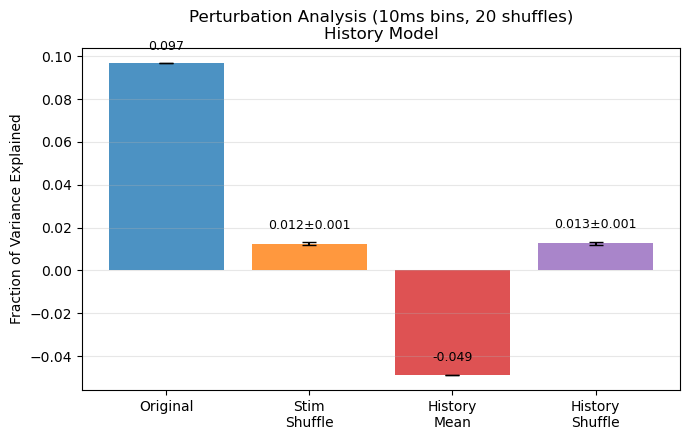

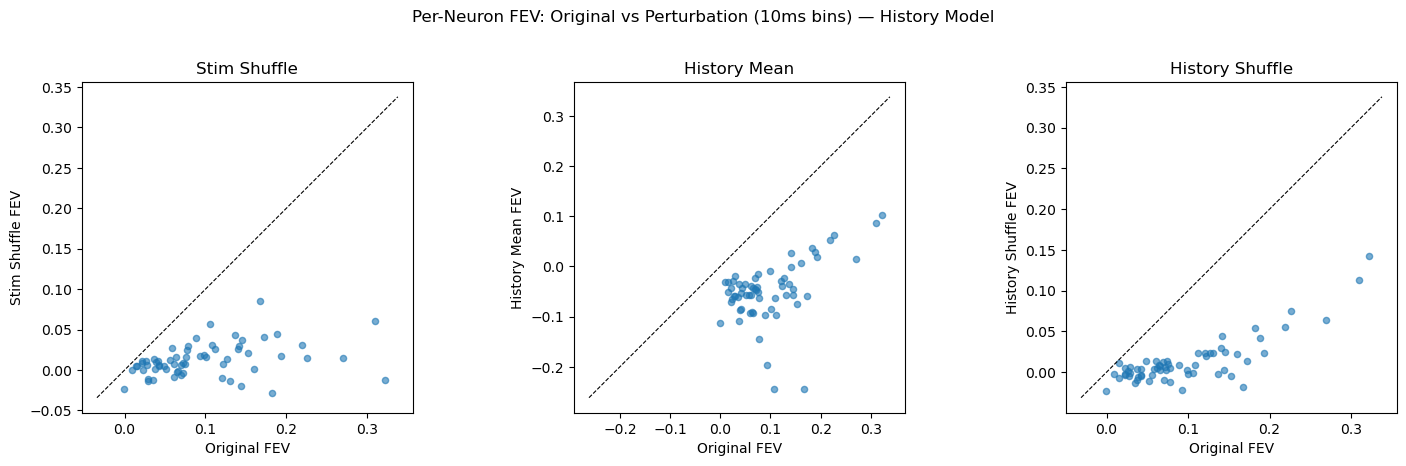

(<Figure size 700x450 with 1 Axes>, <Figure size 1500x450 with 3 Axes>)

In [31]:
from models import perturbation_analysis
import matplotlib.pyplot as plt

N_SHUFFLES = 20

def plot_perturbation_results(results, coarse_bin_ms, n_shuffles, save_prefix=None, model_label=''):
    """Bar plot + per-neuron scatter for perturbation_analysis output.
    
    Automatically adapts to whether history perturbations are present.
    """
    has_history = 'history_shuffle' in results

    # --- Summary table ---
    suffix = f' ({model_label})' if model_label else ''
    print(f"=== Perturbation Analysis{suffix} ({n_shuffles} shuffles, {coarse_bin_ms}ms bins) ===\n")
    print(f"{'Condition':<25s}  {'Mean FEV':>10s}  {'Std':>8s}")
    print("-" * 50)
    print(f"{'Original':<25s}  {results['original']['fve_mean']:>10.4f}")
    pert_keys = ['stim_shuffle']
    if has_history:
        pert_keys += ['history_mean', 'history_shuffle']
    for key in pert_keys:
        r = results[key]
        if isinstance(r['fve_mean'], np.ndarray):
            m, s = r['fve_mean'].mean(), r['fve_mean'].std()
            print(f"{key:<25s}  {m:>10.4f}  {s:>8.4f}")
        else:
            print(f"{key:<25s}  {r['fve_mean']:>10.4f}")

    # --- Bar plot ---
    all_keys = ['original', 'stim_shuffle']
    labels = ['Original', 'Stim\nShuffle']
    colors = ['tab:blue', 'tab:orange']
    if has_history:
        all_keys += ['history_mean', 'history_shuffle']
        labels += ['History\nMean', 'History\nShuffle']
        colors += ['tab:red', 'tab:purple']

    means, stds = [], []
    for key in all_keys:
        r = results[key]
        if isinstance(r['fve_mean'], np.ndarray):
            means.append(r['fve_mean'].mean())
            stds.append(r['fve_mean'].std())
        else:
            means.append(r['fve_mean'])
            stds.append(0)

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, means, yerr=stds, capsize=5, color=colors, alpha=0.8)
    ax.set_ylabel('Fraction of Variance Explained')
    title = f'Perturbation Analysis ({coarse_bin_ms}ms bins, {n_shuffles} shuffles)'
    if model_label:
        title += f'\n{model_label}'
    ax.set_title(title)
    ax.grid(axis='y', alpha=0.3)

    for bar, m, s in zip(bars, means, stds):
        txt = f'{m:.3f}' if s == 0 else f'{m:.3f}\u00b1{s:.3f}'
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.005,
                txt, ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'{save_prefix}_bar.png', dpi=300, bbox_inches='tight')
    plt.show()

    # --- Per-neuron scatter ---
    scatter_keys = [('stim_shuffle', 'Stim Shuffle')]
    if has_history:
        scatter_keys += [('history_mean', 'History Mean'),
                         ('history_shuffle', 'History Shuffle')]

    fig2, axes = plt.subplots(1, len(scatter_keys), figsize=(5*len(scatter_keys), 4.5))
    if len(scatter_keys) == 1:
        axes = [axes]
    for ax_i, (key, title) in zip(axes, scatter_keys):
        r = results[key]
        pert_fve = r['fve_neurons'].mean(axis=0) if r['fve_neurons'].ndim == 2 else r['fve_neurons']
        ax_i.scatter(results['original']['fve_neurons'], pert_fve, alpha=0.6, s=20)
        lims = [min(ax_i.get_xlim()[0], ax_i.get_ylim()[0]),
                max(ax_i.get_xlim()[1], ax_i.get_ylim()[1])]
        ax_i.plot(lims, lims, 'k--', lw=0.8)
        ax_i.set_xlabel('Original FEV')
        ax_i.set_ylabel(f'{title} FEV')
        ax_i.set_title(title)
        ax_i.set_aspect('equal')

    suptitle = f'Per-Neuron FEV: Original vs Perturbation ({coarse_bin_ms}ms bins)'
    if model_label:
        suptitle += f' — {model_label}'
    fig2.suptitle(suptitle, y=1.02)
    plt.tight_layout()
    if save_prefix:
        plt.savefig(f'{save_prefix}_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

    return fig, fig2

# --- History model perturbation ---
results_hist = perturbation_analysis(
    history_model, test_loader,
    n_stim_channels=n_stim_channels,
    n_shuffles=N_SHUFFLES,
    coarse_factor=factor,
    seed=42,
)
plot_perturbation_results(
    results_hist, COARSE_BIN_MS, N_SHUFFLES,
    save_prefix=os.path.join(SWEEP_DIR, f'perturbation_history_{COARSE_BIN_MS}ms'),
    model_label='History Model',
)

Shuffle iterations: 100%|██████████| 20/20 [00:13<00:00,  1.43it/s]


=== Perturbation Analysis (No-History Model) (20 shuffles, 60ms bins) ===

Condition                    Mean FEV       Std
--------------------------------------------------
Original                       0.1449
stim_shuffle                  -0.0876    0.0016


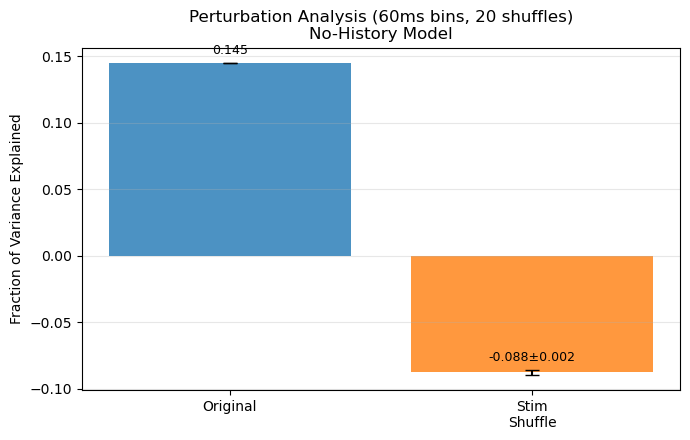

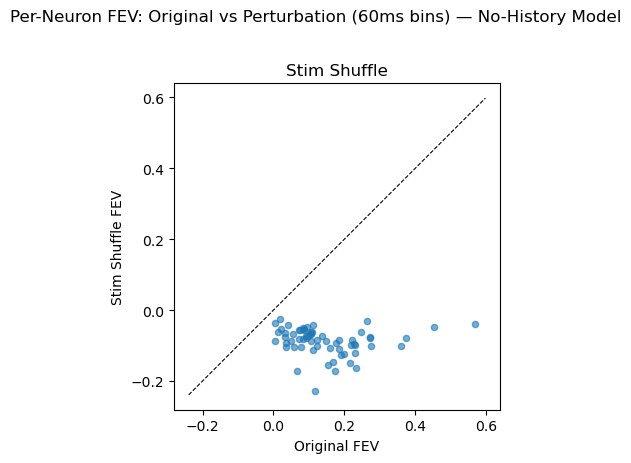

(<Figure size 700x450 with 1 Axes>, <Figure size 500x450 with 1 Axes>)

In [27]:
# --- No-history model perturbation (stim shuffle only) ---
results_nohist = perturbation_analysis(
    nonhistory_model, nonhistory_test_loader,
    n_stim_channels=n_stim_channels,
    n_shuffles=N_SHUFFLES,
    coarse_factor=factor,
    seed=42,
)
plot_perturbation_results(
    results_nohist, COARSE_BIN_MS, N_SHUFFLES,
    save_prefix=os.path.join(SWEEP_DIR, f'perturbation_nohist_{COARSE_BIN_MS}ms'),
    model_label='No-History Model',
)

In [ ]:
# --- Load best model per history value, collect predictions/targets ---
import pandas as pd
import os

COARSE_FACTOR = 1       # 60ms bins; change to 0 for fine (10ms) bins

# 1. Find best trial per history from sweep CSV
sweep_df = pd.read_csv(os.path.join(SWEEP_DIR, 'sweep_results.csv'))
best_idx = sweep_df.groupby('history')['test_corr'].idxmax()
best_df = sweep_df.loc[best_idx].sort_values('history').reset_index(drop=True)

print(f"Loading {len(best_df)} models (coarse_factor={COARSE_FACTOR})...")

# 2. For each history value, load model & store predictions/targets
history_values = []
model_kernel_sizes = []
sweep_preds = []    # list of (pred, true) arrays per history
sweep_loaders = []  # keep loaders for correlation

for _, row in best_df.iterrows():
    run_dir = row['run_dir']
    h = int(row['history'])
    history_values.append(h)
    
    model_tuple, cfg, raw_data, loader = open_model_and_data(run_dir)
    # Extract kernel size (assuming single kernel size in list like [60])
    ks = cfg.get('kernel_sizes', [60])
    model_kernel_sizes.append(str(ks[0]) if isinstance(ks, list) and len(ks) > 0 else str(ks))
    
    pred, true = collect_model_preds_and_targets(model_tuple, loader, coarse_factor=COARSE_FACTOR)
    sweep_preds.append((pred, true))
    sweep_loaders.append(loader)
    print(f"  history={h:>2d}  ks= {model_kernel_sizes[-1]}  run={run_dir.split('/')[-1]}  shape={pred.shape}")

print("Done. Use sweep_preds / sweep_loaders for FEV and correlation plots.")

In [ ]:
# --- FEV vs History ---
import matplotlib.pyplot as plt

# Dynamically compute baselines at sweep's COARSE_FACTOR
_loo_pred, _loo_true = collect_loo_preds_and_targets(sweep_loaders[0].dataset, coarse_factor=COARSE_FACTOR, loo_flag=True)
_, LOO_FVE_MEAN = fraction_variance_explained(_loo_true, _loo_pred, global_variance=True)

_nh_pred, _nh_true = collect_model_preds_and_targets(nonhistory_model, nonhistory_test_loader, coarse_factor=COARSE_FACTOR)
_, nohist_fve_mean = fraction_variance_explained(_nh_true, _nh_pred, global_variance=True)

fve_means = []
for pred, true in sweep_preds:
    _, fve_mean = fraction_variance_explained(true, pred, global_variance=True)
    fve_means.append(fve_mean)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history_values, fve_means, 'o-', color='tab:blue', label='History CNN (best per h)')

# Annotate with Kernel Size
for i, h in enumerate(history_values):
    ks = model_kernel_sizes[i]
    ax.text(h, fve_means[i] + 0.005, f'k={ks}', ha='center', va='bottom', fontsize=8, color='tab:blue')

ax.axhline(nohist_fve_mean, color='tab:orange', ls='--', lw=1.5, label=f'No-history CNN ({nohist_fve_mean:.3f})')
ax.axhline(LOO_FVE_MEAN, color='tab:green', ls=':', lw=1.5, label=f'LOO baseline ({LOO_FVE_MEAN:.3f})')
ax.set_xlabel('History (bins)')
ax.set_ylabel('Fraction of Explained Variance')

coarse_bin_ms = fine_bin_ms * COARSE_FACTOR if COARSE_FACTOR > 0 else fine_bin_ms
ax.set_title(f'FEV vs History Length ({coarse_bin_ms}ms bins, global variance)')
ax.set_xticks(history_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(SWEEP_DIR, f'FEV_vs_history_coarse{coarse_bin_ms}ms.png'), dpi=300, bbox_inches='tight', transparent=False)
plt.show()

In [ ]:
%matplotlib inline
# --- Temporal Correlation vs History ---

# Dynamically compute baselines at sweep's COARSE_FACTOR
loo_corrs = get_loo_temporal_corr(sweep_loaders[0].dataset, coarse_factor=COARSE_FACTOR)
loo_corr_mean = loo_corrs.mean()

nohist_corrs = get_per_neuron_temporal_corr(nonhistory_model, nonhistory_test_loader, coarse_factor=COARSE_FACTOR)
nohist_corr_mean = nohist_corrs.mean()

corr_means = []
for pred, true in sweep_preds:
    n_neurons_here = pred.shape[1]
    neuron_corrs = np.zeros(n_neurons_here)
    for n in range(n_neurons_here):
        p = pred[:, n, :].ravel()
        t = true[:, n, :].ravel()
        if p.std() > 1e-8 and t.std() > 1e-8:
            neuron_corrs[n] = pearsonr(p, t)[0]
    corr_means.append(neuron_corrs.mean())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(history_values, corr_means, 'o-', color='tab:blue', label='History CNN (best per h)')
ax.axhline(nohist_corr_mean, color='tab:orange', ls='--', lw=1.5, label=f'No-history CNN ({nohist_corr_mean:.3f})')
ax.axhline(loo_corr_mean, color='tab:green', ls=':', lw=1.5, label=f'LOO baseline ({loo_corr_mean:.3f})')
ax.set_xlabel('History (bins)')
ax.set_ylabel('Mean Temporal Correlation (Pearson r)')
coarse_bin_ms = fine_bin_ms * COARSE_FACTOR if COARSE_FACTOR > 0 else fine_bin_ms
ax.set_title(f'Correlation vs History Length ({coarse_bin_ms}ms bins)')
ax.set_xticks(history_values)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
f = test_loader.dataset.visualize_sample(45, cfg=init_cfg)
plt.show()

In [ ]:

from viz import plot_neuron_pattern_traces
# # --- Single example ---
fig = plot_neuron_pattern_traces(5, 4031, history_model, history_cfg, history_raw, test_loader,
                                 coarse_factor=6, save_dir='results/scratch/single_trace_examples_coarse6')

# --- Generate all (uncomment to run; saves ~3150 figures) ---
# generate_all_neuron_pattern_plots(history_model, history_cfg, history_raw, test_loader,
#                                    coarse_factor=1,
#                                    save_dir='results/neuron_pattern_traces_coarse1')

In [45]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from models import HistoryCacheCausalCNN, train_epoch, validate
from utils import BinnedStimSpikeDataset

# ---- Config for cache model ----
CACHE_SIZE = 5
CACHE_EMBED_DIM = 32
CONV_CHANNELS = [256]
KERNEL_SIZES = [5]
FC_DIMS = [256]
DROPOUT = 0.2
N_EPOCHS = 50
LR = 1e-3
BATCH_SIZE = 16

# ---- Use history_raw (already loaded in cell 2) ----
raw = history_raw
pattern_df = raw["pattern_df"]
unique_trials_info = pattern_df[["pattern_timing_index", "pattern_name", "is_oracle"]].drop_duplicates()
oracle_timing = unique_trials_info[unique_trials_info["is_oracle"]]["pattern_timing_index"].tolist()
sample_timing = unique_trials_info[~unique_trials_info["is_oracle"]]["pattern_timing_index"].tolist()
train_indices, val_indices = train_test_split(sample_timing, test_size=0.15, random_state=42)
test_indices = oracle_timing

# ---- Build datasets with history=0 (stim only) ----
# The cache model handles spike context separately, so we don't bake
# spike history into the dataset input.  No init_state — the model uses
# causal (left) padding to keep input and output lengths equal.
ds_kwargs = dict(
    pattern_df=raw["pattern_df"],
    spike_responses=raw["spike_responses"],
    channel_to_index=raw["channel_to_index"],
    timing_to_pattern=raw["timing_to_pattern"],
    input_bin_size_ms=10,
    output_bin_size_ms=10,
    n_input_bins=60,
    n_output_bins=60,
    max_time_ms=600,
    output_offset=0,
    encoding_mode='current',
    init_state=False,
    n_initial_state_bins=0,
    history=0,
    logger=None,
)

train_ds = BinnedStimSpikeDataset(trial_indices=train_indices, **ds_kwargs)
val_ds   = BinnedStimSpikeDataset(trial_indices=val_indices,   **ds_kwargs)
test_ds  = BinnedStimSpikeDataset(trial_indices=test_indices,  **ds_kwargs)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader_cache = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_ds)} samples, Val: {len(val_ds)}, Test: {len(test_ds)}")

# ---- Instantiate model ----
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
cache_model = HistoryCacheCausalCNN(
    n_stim_channels=n_stim_channels,
    n_neurons=n_neurons,
    n_input_bins=60,
    n_output_bins=60,
    conv_channels=CONV_CHANNELS,
    kernel_sizes=KERNEL_SIZES,
    fc_dims=FC_DIMS,
    dropout=DROPOUT,
    cache_size=CACHE_SIZE,
    cache_embed_dim=CACHE_EMBED_DIM,
    use_batch_norm=True,
    use_init_state=False,  # causal padding — matches init_state=False in dataset
).to(device)

n_params = sum(p.numel() for p in cache_model.parameters())
print(f"HistoryCacheCausalCNN: {n_params:,} parameters")
print(f"  Conv input channels: {n_stim_channels} + {n_neurons}*{CACHE_EMBED_DIM} = "
      f"{n_stim_channels + n_neurons * CACHE_EMBED_DIM}")
print(f"  Cache size: {CACHE_SIZE}, embed dim: {CACHE_EMBED_DIM}")

# ---- Verify shapes with a sample batch ----
bx, by = next(iter(train_loader))
print(f"\nSample batch: stim_input={bx.shape}, target={by.shape}")

# spike_context = GT spikes, same time axis as stim (no init-state offset)
spike_ctx = by.to(device)

with torch.no_grad():
    out_tf = cache_model(bx.to(device), spike_ctx, mode='teacher_forcing')
    print(f"Teacher forcing output: {out_tf.shape}")  # expect (B, 63, 60)

# ---- Custom training loop (cache model needs spike_context) ----
criterion = nn.PoissonNLLLoss(log_input=True, reduction='mean')
optimizer = torch.optim.Adam(cache_model.parameters(), lr=LR, weight_decay=1e-5)

for epoch in range(N_EPOCHS):
    cache_model.train()
    total_loss = 0
    n_batches = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)

        optimizer.zero_grad()
        pred = cache_model(bx, by, mode='teacher_forcing')
        loss = criterion(pred, by)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(cache_model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item()
        n_batches += 1

    train_loss = total_loss / n_batches

    # ---- Validation ----
    cache_model.eval()
    val_loss = 0
    val_batches = 0
    with torch.no_grad():
        for bx, by in val_loader:
            bx, by = bx.to(device), by.to(device)
            pred = cache_model(bx, by, mode='teacher_forcing')
            val_loss += criterion(pred, by).item()
            val_batches += 1
    val_loss /= val_batches

    print(f"Epoch {epoch+1}/{N_EPOCHS} — train_loss: {train_loss:.4f}  val_loss: {val_loss:.4f}")

print("\nTraining complete.")

0 trials were added in spike responses for initial state that were not in the specified trial_indices
0 trials were added in spike responses for initial state that were not in the specified trial_indices
0 trials were added in spike responses for initial state that were not in the specified trial_indices
Train: 3400 samples, Val: 600, Test: 1000
HistoryCacheCausalCNN: 2,717,183 parameters
  Conv input channels: 42 + 63*32 = 2058
  Cache size: 5, embed dim: 32

Sample batch: stim_input=torch.Size([16, 42, 60]), target=torch.Size([16, 63, 60])
Teacher forcing output: torch.Size([16, 63, 60])
Epoch 1/50 — train_loss: 0.2148  val_loss: 0.1823
Epoch 2/50 — train_loss: 0.1816  val_loss: 0.1768
Epoch 3/50 — train_loss: 0.1777  val_loss: 0.1746
Epoch 4/50 — train_loss: 0.1751  val_loss: 0.1742
Epoch 5/50 — train_loss: 0.1730  val_loss: 0.1711
Epoch 6/50 — train_loss: 0.1710  val_loss: 0.1694
Epoch 7/50 — train_loss: 0.1693  val_loss: 0.1684
Epoch 8/50 — train_loss: 0.1680  val_loss: 0.1675
Epo

Computing AR predictions (sequential, may take a moment)...

=== Cache CNN (60ms bins) ===
Mode                   Mean r    Med r   Mean FVE    Med FVE  > LOO (r)  > LOO (FVE)
--------------------------------------------------------------------------------
Teacher Forcing        0.5449   0.5533     0.3065     0.2849   39/63     39/63  
Autoregressive         0.0413   0.0242    -5.4477    -4.3886    0/63      0/63  


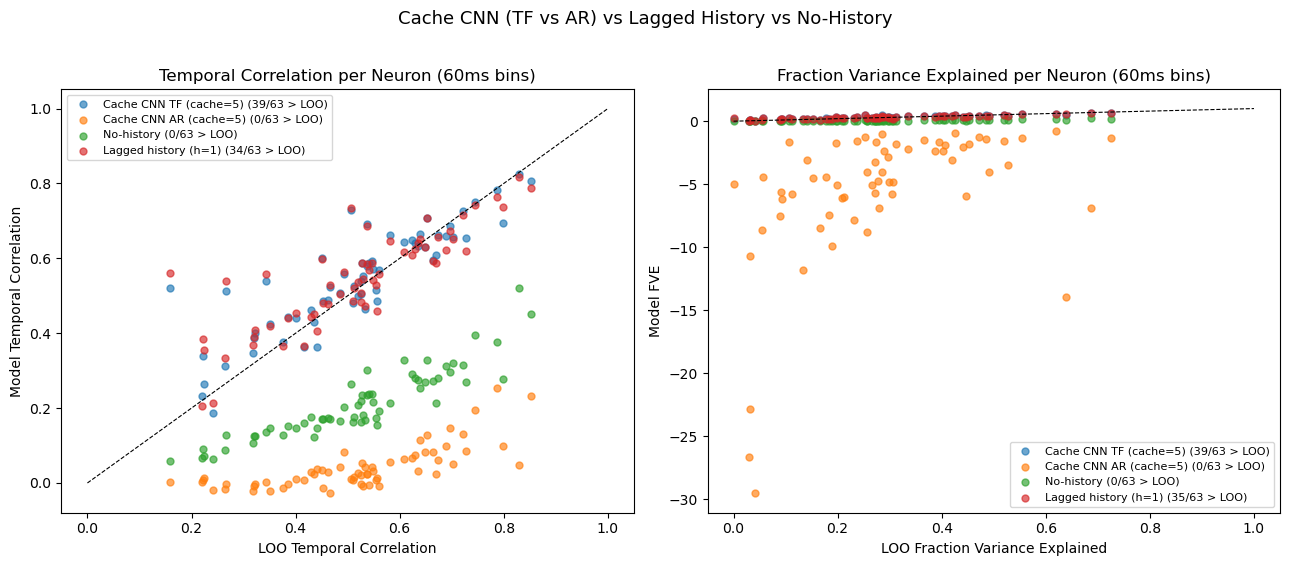

In [56]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from metrics import _coarsen

# Use the same coarse bin size as cell 3 so LOO / hist / nohist comparisons are consistent
COARSE_BIN_MS = 60
coarse_factor = COARSE_BIN_MS // fine_bin_ms  # must match cell 3's factor

cache_model.eval()

# ---- 1. Teacher-forcing predictions ----
cache_preds_tf, cache_trues = [], []
with torch.no_grad():
    for bx, by in test_loader_cache:
        bx, by_dev = bx.to(device), by.to(device)
        pred = torch.exp(cache_model(bx, by_dev, mode='teacher_forcing')).cpu().numpy()
        cache_preds_tf.append(pred)
        cache_trues.append(by.numpy())

cache_pred_tf = np.concatenate(cache_preds_tf, axis=0)
cache_true    = np.concatenate(cache_trues, axis=0)

# ---- 2. Fully-autoregressive predictions ----
print("Computing AR predictions (sequential, may take a moment)...")
cache_preds_ar = []
with torch.no_grad():
    for bx, by in test_loader_cache:
        bx = bx.to(device)
        pred = torch.exp(cache_model(bx, spike_context=None, mode='ar')).cpu().numpy()
        cache_preds_ar.append(pred)

cache_pred_ar = np.concatenate(cache_preds_ar, axis=0)

# ---- 3. Coarsen all arrays ----
if coarse_factor > 1:
    cache_pred_tf = _coarsen(cache_pred_tf, factor=coarse_factor)
    cache_pred_ar = _coarsen(cache_pred_ar, factor=coarse_factor)
    cache_true    = _coarsen(cache_true,    factor=coarse_factor)

# ---- 4. Per-neuron metrics ----
n_neurons_here = cache_pred_tf.shape[1]

tf_corrs = np.zeros(n_neurons_here)
ar_cache_corrs = np.zeros(n_neurons_here)
for n in range(n_neurons_here):
    pt = cache_pred_tf[:, n, :].ravel();  tt = cache_true[:, n, :].ravel()
    pa = cache_pred_ar[:, n, :].ravel()
    if pt.std() > 1e-8 and tt.std() > 1e-8:
        tf_corrs[n] = pearsonr(pt, tt)[0]
    if pa.std() > 1e-8 and tt.std() > 1e-8:
        ar_cache_corrs[n] = pearsonr(pa, tt)[0]

tf_fve_neurons, tf_fve_mean = fraction_variance_explained(
    cache_true, cache_pred_tf, global_variance=True)
ar_fve_cache_neurons, ar_fve_cache_mean = fraction_variance_explained(
    cache_true, cache_pred_ar, global_variance=True)

print(f"\n=== Cache CNN ({COARSE_BIN_MS}ms bins) ===")
print(f"{'Mode':<20} {'Mean r':>8} {'Med r':>8} {'Mean FVE':>10} {'Med FVE':>10} {'> LOO (r)':>10} {'> LOO (FVE)':>12}")
print("-" * 80)
for tag, corrs, fve in [("Teacher Forcing", tf_corrs, tf_fve_neurons),
                         ("Autoregressive",  ar_cache_corrs, ar_fve_cache_neurons)]:
    print(f"{tag:<20} {corrs.mean():8.4f} {np.median(corrs):8.4f} "
          f"{fve.mean():10.4f} {np.median(fve):10.4f} "
          f"{(corrs > loo_corrs).sum():>4}/{len(loo_corrs):<4} "
          f"{(fve > loo_fve_neurons).sum():>4}/{len(loo_fve_neurons):<4}")

# ---- 5. Register in MODEL_DATA ----
hist_h = history_cfg.get('history', 1)
MODEL_DATA['cache_tf'] = {
    'corrs': tf_corrs, 'fve': tf_fve_neurons,
    'label': f'Cache CNN TF (cache={CACHE_SIZE})',
}
MODEL_DATA['cache_ar'] = {
    'corrs': ar_cache_corrs, 'fve': ar_fve_cache_neurons,
    'label': f'Cache CNN AR (cache={CACHE_SIZE})',
}
MODEL_DATA['hist_gt'] = {
    'corrs': hist_corrs, 'fve': hist_fve_neurons,
    'label': f'Lagged history (h={hist_h})',
}

# ---- 6. Combined 4-model overlay plot ----
models_to_plot = ['cache_tf', 'cache_ar', 'nohist', 'hist_gt']
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))
n_total = len(loo_corrs)

for key, c in zip(models_to_plot, colors):
    d = MODEL_DATA[key]
    n_better_corr = (d['corrs'] > loo_corrs).sum()
    n_better_fve  = (d['fve']   > loo_fve_neurons).sum()

    ax[0].scatter(loo_corrs, d['corrs'], color=c, alpha=0.65, s=25,
                  label=f"{d['label']} ({n_better_corr}/{n_total} > LOO)")
    ax[1].scatter(loo_fve_neurons, d['fve'], color=c, alpha=0.65, s=25,
                  label=f"{d['label']} ({n_better_fve}/{n_total} > LOO)")

for a in ax:
    a.plot([0, 1], [0, 1], 'k--', lw=0.8)
    a.legend(fontsize=8)

ax[0].set_xlabel("LOO Temporal Correlation")
ax[0].set_ylabel("Model Temporal Correlation")
ax[0].set_title(f"Temporal Correlation per Neuron ({COARSE_BIN_MS}ms bins)")

ax[1].set_xlabel("LOO Fraction Variance Explained")
ax[1].set_ylabel("Model FVE")
ax[1].set_title(f"Fraction Variance Explained per Neuron ({COARSE_BIN_MS}ms bins)")

fig.suptitle("Cache CNN (TF vs AR) vs Lagged History vs No-History", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [54]:
# Quick diagnostic: are AR predictions exploding?
print("=== Prediction magnitude diagnostics ===")
print(f"{'':20s}  {'mean':>10s}  {'median':>10s}  {'max':>10s}  {'min':>10s}")
print("-" * 65)
for label, arr in [("Ground truth", cache_true),
                   ("TF predictions", cache_pred_tf),
                   ("AR predictions", cache_pred_ar)]:
    print(f"{label:20s}  {arr.mean():10.4f}  {np.median(arr):10.4f}  {arr.max():10.4f}  {arr.min():10.4f}")

print(f"\nAR predictions > 10x GT max: {(cache_pred_ar > 10 * cache_true.max()).sum()} / {cache_pred_ar.size}")
print(f"AR predictions contain NaN:  {np.isnan(cache_pred_ar).sum()}")
print(f"AR predictions contain Inf:  {np.isinf(cache_pred_ar).sum()}")

=== Prediction magnitude diagnostics ===
                            mean      median         max         min
-----------------------------------------------------------------
Ground truth              0.0500      0.0000      1.8333      0.0000
TF predictions            0.0535      0.0277      1.1564      0.0001
AR predictions            0.1048      0.0272      1.1932      0.0005

AR predictions > 10x GT max: 0 / 630000
AR predictions contain NaN:  0
AR predictions contain Inf:  0
